In [1]:
import torch

if torch.cuda.is_available():
    print("GPU detected!")
    print("Device name:", torch.cuda.get_device_name(0))
    print("Current device index:", torch.cuda.current_device())
    print("Memory allocated:", torch.cuda.memory_allocated(0) / 1e6, "MB")
else:
    print("No GPU detected, running on CPU")

GPU detected!
Device name: NVIDIA GeForce RTX 2050
Current device index: 0
Memory allocated: 0.0 MB


In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# For preprocessing and splitting (same as before)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# For audio processing (same as before)
import librosa
import librosa.display

In [3]:
import torch

def generate_mel_spectrogram(audio_path, sr=22050, duration=30, n_mels=128, max_len=1300, device='cpu'):
    """
    Generates a normalized mel-spectrogram tensor from an audio file.
    
    Args:
        audio_path (str): Path to audio file
        sr (int): Sampling rate
        duration (float): Duration to load (seconds)
        n_mels (int): Number of Mel bands
        max_len (int): Fixed width for padding/cropping
        device (str): 'cpu' or 'cuda' device for tensor

    Returns:
        torch.Tensor of shape (1, n_mels, max_len)
    """
    try:
        # Load audio
        y, sr = librosa.load(audio_path, sr=sr, duration=duration)

        # Compute mel spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalize to 0-1
        mel_spec_db = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8)

        # Pad or crop
        if mel_spec_db.shape[1] < max_len:
            pad_width = max_len - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :max_len]

        # Convert to PyTorch tensor and add channel dimension
        mel_tensor = torch.tensor(mel_spec_db, dtype=torch.float32).unsqueeze(0).to(device)  # shape: (1, n_mels, max_len)
        return mel_tensor

    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return None

In [4]:
from torch.utils.data import Dataset, DataLoader

# 1. Collect genres and encode labels
genres_path = r"C:\Users\shash\Downloads\archive (2)\Data\genres_original"
genres = [d for d in os.listdir(genres_path) if os.path.isdir(os.path.join(genres_path, d))]
print(f"Genres: {genres}")

le = LabelEncoder()
le.fit(genres)

# 2. Load audio files and generate spectrograms
X = []
y = []

for genre in genres:
    genre_path = os.path.join(genres_path, genre)
    print(f"Processing {genre}...")
    
    wav_files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]
    
    for file_name in tqdm(wav_files, desc=f"  {genre}"):
        file_path = os.path.join(genre_path, file_name)
        spectrogram = generate_mel_spectrogram(file_path)
        
        if spectrogram is not None:
            X.append(spectrogram)  # Already (1, n_mels, max_len) from the function
            y.append(genre)

# 3. Convert to tensors
X = torch.stack(X).float()  # shape: (num_samples, 1, n_mels, max_len)
y_labels = torch.tensor(le.transform(y)).long()  # integer labels for CrossEntropyLoss

print(f"\nData shape: {X.shape}")
print(f"Labels shape: {y_labels.shape}")
print(f"Number of samples: {len(X)}")
print(f"Number of classes: {len(genres)}")

# 4. Split into train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# 5. PyTorch Dataset
class MelDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MelDataset(X_train, y_train)
test_dataset = MelDataset(X_test, y_test)

# 6. DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Processing blues...


  blues: 100%|██████████| 100/100 [00:08<00:00, 11.81it/s]


Processing classical...


  classical: 100%|██████████| 100/100 [00:06<00:00, 16.43it/s]


Processing country...


...

Processing reggae...


  reggae: 100%|██████████| 100/100 [00:05<00:00, 16.68it/s]


Processing rock...


  rock: 100%|██████████| 100/100 [00:06<00:00, 16.50it/s]



Data shape: torch.Size([999, 1, 128, 1300])
Labels shape: torch.Size([999])
Number of samples: 999
Number of classes: 10

Training set: torch.Size([799, 1, 128, 1300])
Test set: torch.Size([200, 1, 128, 1300])


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. CNN model
class CNNModel(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(CNNModel, self).__init__()
        
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        
        self.conv_block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.AdaptiveAvgPool2d(1),  # GlobalAveragePooling
            nn.Dropout(0.5)
        )
        
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = self.conv_block4(x)
        x = x.view(x.size(0), -1)  # flatten
        x = self.fc(x)
        return x  # logits

# 2. Instantiate model
input_channels = X_train.shape[1]  # 1 for mel-spectrograms
num_classes = len(genres)
model = CNNModel(input_channels, num_classes)

# 3. Loss and optimizer
criterion = nn.CrossEntropyLoss()  # expects integer labels
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 4. Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)
print(model)

CNNModel(
  (conv_block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (conv_block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2

In [6]:
import copy
import numpy as np
from tqdm import tqdm  # tqdm for progress bar
import time

# 1. Hyperparameters
num_epochs = 100
patience_early = 15
patience_lr = 5
factor_lr = 0.5
min_lr = 1e-7
best_val_acc = 0.0
epochs_no_improve = 0
epochs_no_improve_lr = 0
best_model_wts = copy.deepcopy(model.state_dict())

# 2. Training loop
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    start_time = time.time()
    
    model.train()
    running_loss = 0.0
    running_corrects = 0

    # --- Training with tqdm ---
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
    for inputs, labels in train_loop:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)

        # Update tqdm postfix
        train_loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc.item())

    # --- Validation with tqdm ---
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0
    val_loop = tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False)
    with torch.no_grad():
        for inputs, labels in val_loop:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, 1)
            val_running_corrects += torch.sum(preds == labels.data)

            val_loop.set_postfix(loss=loss.item())

    val_loss = val_running_loss / len(test_dataset)
    val_acc = val_running_corrects.double() / len(test_dataset)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc.item())

    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} "
          f"Time: {epoch_time:.1f}s")

    # --- Early stopping & best model checkpoint (val accuracy) ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
        # Save best model
        torch.save(model.state_dict(), "best_cnn_model.pth")
        print("Best model saved!")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience_early:
        print(f"Early stopping triggered after {epoch+1} epochs")
        break

    # --- ReduceLROnPlateau ---
    if len(val_losses) > 1 and val_loss >= val_losses[-2]:
        epochs_no_improve_lr += 1
        if epochs_no_improve_lr >= patience_lr:
            for g in optimizer.param_groups:
                old_lr = g['lr']
                new_lr = max(old_lr * factor_lr, min_lr)
                if new_lr < old_lr:
                    g['lr'] = new_lr
                    print(f"Reducing learning rate: {old_lr:.6f} -> {new_lr:.6f}")
            epochs_no_improve_lr = 0
    else:
        epochs_no_improve_lr = 0

# Load best weights at the end
model.load_state_dict(best_model_wts)

Epoch 1/100 Train Loss: 1.7106 Acc: 0.4005 Val Loss: 4.8142 Acc: 0.1050 Time: 71.3s
Best model saved!


Epoch 2/100 Train Loss: 1.3755 Acc: 0.5156 Val Loss: 3.5993 Acc: 0.2100 Time: 64.7s
Best model saved!


Epoch 3/100 Train Loss: 1.2956 Acc: 0.5569 Val Loss: 1.9692 Acc: 0.4650 Time: 65.5s
Best model saved!


Epoch 4/100 Train Loss: 1.2214 Acc: 0.5895 Val Loss: 1.4316 Acc: 0.5150 Time: 69.9s
Best model saved!


Epoch 5/100 Train Loss: 1.1644 Acc: 0.6208 Val Loss: 1.5793 Acc: 0.5150 Time: 65.0s


...

Epoch 69/100 Train Loss: 0.0568 Acc: 0.9850 Val Loss: 1.6024 Acc: 0.6650 Time: 75.1s


Epoch 70/100 Train Loss: 0.0463 Acc: 0.9925 Val Loss: 1.2523 Acc: 0.7550 Time: 74.1s


Epoch 71/100 Train Loss: 0.0586 Acc: 0.9862 Val Loss: 0.8373 Acc: 0.7800 Time: 71.2s


Epoch 72/100 Train Loss: 0.0440 Acc: 0.9912 Val Loss: 1.2814 Acc: 0.7450 Time: 70.7s
Early stopping triggered after 72 epochs


<All keys matched successfully>

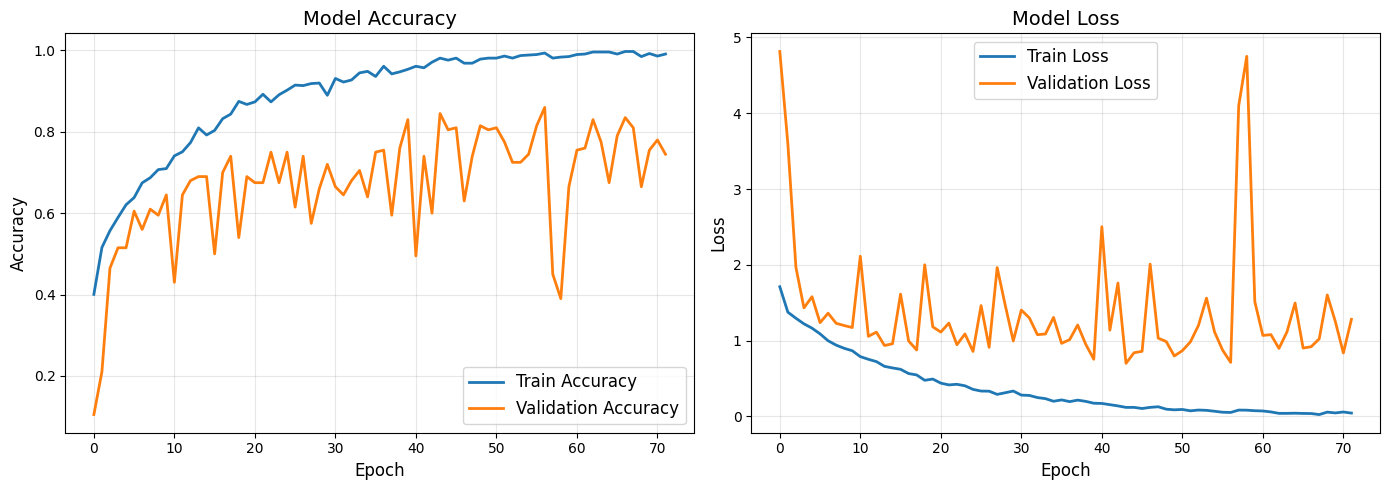


Test Accuracy: 0.8600
Test Loss: 0.7131

Classification Report:
              precision    recall  f1-score   support

       blues       0.94      0.75      0.83        20
   classical       0.95      1.00      0.98        20
     country       0.76      0.95      0.84        20
       disco       0.78      0.70      0.74        20
      hiphop       0.83      0.95      0.88        20
        jazz       0.95      1.00      0.98        20
       metal       0.90      0.95      0.93        20
         pop       0.75      0.90      0.82        20
      reggae       1.00      0.75      0.86        20
        rock       0.81      0.65      0.72        20

    accuracy                           0.86       200
   macro avg       0.87      0.86      0.86       200
weighted avg       0.87      0.86      0.86       200



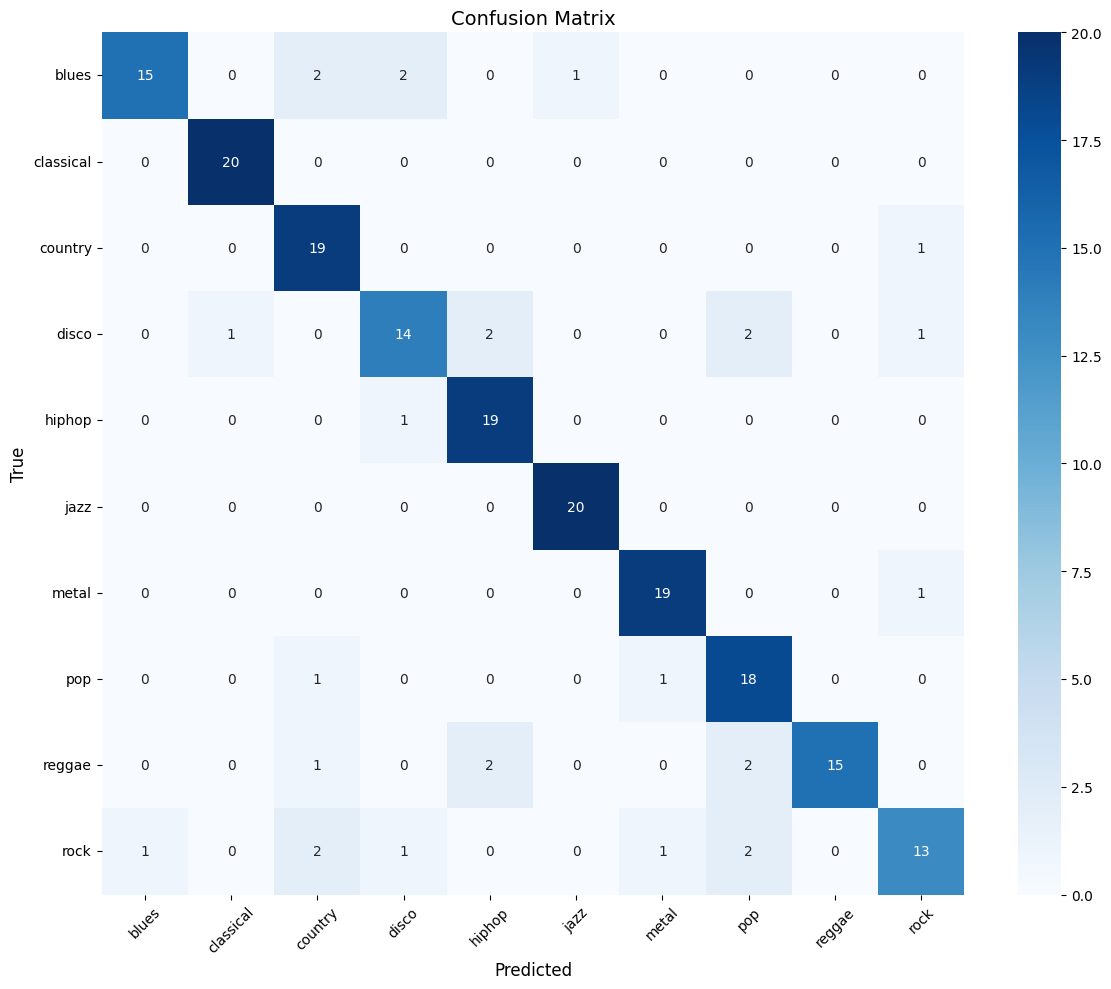

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# -----------------------------
# 1. Plot training & validation curves
# -----------------------------
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accuracies, label='Train Accuracy', linewidth=2)
plt.plot(val_accuracies, label='Validation Accuracy', linewidth=2)
plt.title('Model Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.title('Model Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# 2. Evaluate on test set
# -----------------------------
model.eval()
test_running_loss = 0.0
test_running_corrects = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        test_running_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, 1)
        test_running_corrects += torch.sum(preds == labels.data)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_running_loss / len(test_dataset)
test_accuracy = test_running_corrects.double() / len(test_dataset)

print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# -----------------------------
# 3. Classification report
# -----------------------------
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=genres))

# -----------------------------
# 4. Confusion matrix
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=genres, yticklabels=genres)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [8]:
"""
Improved Music Genre Classification - CNN Model v2
===================================================
Fixes applied vs baseline:
  1. Audio segmentation  - 3s windows w/ 50% overlap (~10x more samples)
  2. SpecAugment         - FrequencyMasking + TimeMasking on train set
  3. Pretrained backbone - EfficientNet-B0 (ImageNet weights, fine-tuned)
  4. Stronger dropout    - added intermediate FC dropout layer
  5. Weight decay        - L2 regularisation via Adam weight_decay=1e-4
  6. Proper splits       - 70% train / 15% val / 15% test (no data leakage)
  7. LR scheduling       - CosineAnnealingLR instead of manual ReduceLROnPlateau
  8. Gradient clipping   - prevents loss spikes seen in baseline
"""

# ─────────────────────────────────────────────────────────────────────────────
# 0. Imports
# ─────────────────────────────────────────────────────────────────────────────
import os
import copy
import time
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio.transforms as TAT
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm import tqdm

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Audio → Mel-spectrogram segments
# ─────────────────────────────────────────────────────────────────────────────
def generate_mel_segments(
    audio_path,
    sr=22050,
    segment_duration=3.0,   # seconds per window
    hop_duration=1.5,        # 50 % overlap
    n_mels=128,
    n_fft=2048,
    hop_length=512,
):
    """
    Splits one audio file into multiple fixed-length segments and returns
    a list of normalised mel-spectrogram tensors, shape (1, n_mels, T).

    A 30-second clip with segment=3s, hop=1.5s yields ~19 segments,
    turning 800 training files into ~15 000 training samples.
    """
    try:
        y, sr = librosa.load(audio_path, sr=sr)
    except Exception as e:
        print(f"  [skip] {audio_path}: {e}")
        return []

    segment_len = int(segment_duration * sr)
    hop_len_samples = int(hop_duration * sr)

    segments = []
    start = 0
    while start + segment_len <= len(y):
        chunk = y[start : start + segment_len]

        mel = librosa.feature.melspectrogram(
            y=chunk, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
        )
        mel_db = librosa.power_to_db(mel, ref=np.max)

        # Normalise to [0, 1]
        mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

        tensor = torch.tensor(mel_db, dtype=torch.float32).unsqueeze(0)  # (1, n_mels, T)
        segments.append(tensor)
        start += hop_len_samples

    return segments

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Dataset with SpecAugment (train only)
# ─────────────────────────────────────────────────────────────────────────────
class MelDataset(Dataset):
    """
    augment=True applies SpecAugment (FrequencyMasking + TimeMasking).
    Only pass augment=True for the training split.
    """

    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment
        # Mask up to 20 mel bins and up to 40 time frames
        self.freq_mask = TAT.FrequencyMasking(freq_mask_param=20)
        self.time_mask = TAT.TimeMasking(time_mask_param=40)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            x = self.freq_mask(x)
            x = self.time_mask(x)
        return x, self.y[idx]

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Model — EfficientNet-B0 backbone + custom head
# ─────────────────────────────────────────────────────────────────────────────
class ImprovedGenreClassifier(nn.Module):
    """
    EfficientNet-B0 pretrained on ImageNet, adapted for single-channel
    mel-spectrograms.

    Strategy
    --------
    • Replace the first Conv2d to accept 1-channel input (average the 3
      pretrained channel weights so knowledge is preserved).
    • Keep all intermediate layers frozen for the first `freeze_epochs`
      epochs; then unfreeze for fine-tuning (handled in the training loop).
    • Replace the classifier head with a 2-layer MLP with dropout.
    """

    def __init__(self, num_classes: int):
        super().__init__()

        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        backbone = models.efficientnet_b0(weights=weights)

        # ── Adapt first conv to 1 channel ──────────────────────────────────
        old_conv = backbone.features[0][0]          # Conv2d(3, 32, ...)
        new_conv = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=old_conv.bias is not None,
        )
        # Initialise with the mean of the 3 pretrained channel weights
        with torch.no_grad():
            new_conv.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.features[0][0] = new_conv

        self.backbone = backbone.features          # feature extractor
        self.pool = nn.AdaptiveAvgPool2d(1)

        # ── Custom classifier head ──────────────────────────────────────────
        in_features = backbone.classifier[1].in_features   # 1280 for B0
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        # EfficientNet expects 3-channel RGB; we feed 1-channel mel.
        # Replicate channel so BatchNorm stats stay valid.
        x = self.backbone(x)
        x = self.pool(x)
        x = x.flatten(1)
        return self.classifier(x)

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 4. Data loading helpers
# ─────────────────────────────────────────────────────────────────────────────
def load_dataset(genres_path: str):
    """
    Walks genres_path, generates mel segments for every .wav file, and
    returns (X, y_labels, label_encoder).

    File-level stratified split is performed BEFORE expanding into segments
    to avoid the same audio clip leaking across train/val/test.
    """
    genres = sorted(
        d for d in os.listdir(genres_path)
        if os.path.isdir(os.path.join(genres_path, d))
    )
    print(f"Genres ({len(genres)}): {genres}\n")

    le = LabelEncoder()
    le.fit(genres)

    # Collect (file_path, label) pairs
    file_paths, file_labels = [], []
    for genre in genres:
        genre_dir = os.path.join(genres_path, genre)
        for fname in os.listdir(genre_dir):
            if fname.endswith(".wav"):
                file_paths.append(os.path.join(genre_dir, fname))
                file_labels.append(genre)

    file_labels_enc = le.transform(file_labels)

    # ── File-level 70 / 15 / 15 split (stratified) ─────────────────────────
    fp_train, fp_tmp, fl_train, fl_tmp = train_test_split(
        file_paths, file_labels_enc, test_size=0.30,
        random_state=42, stratify=file_labels_enc
    )
    fp_val, fp_test, fl_val, fl_test = train_test_split(
        fp_tmp, fl_tmp, test_size=0.50,
        random_state=42, stratify=fl_tmp
    )

    print(f"Files  → train: {len(fp_train)}  val: {len(fp_val)}  test: {len(fp_test)}")

    def expand(fps, fls, desc):
        X, y = [], []
        for fp, label in tqdm(zip(fps, fls), total=len(fps), desc=desc):
            segs = generate_mel_segments(fp)
            for s in segs:
                X.append(s)
                y.append(label)
        return X, y

    X_train, y_train = expand(fp_train, fl_train, "Train segments")
    X_val,   y_val   = expand(fp_val,   fl_val,   "Val   segments")
    X_test,  y_test  = expand(fp_test,  fl_test,  "Test  segments")

    print(f"\nSegments → train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")

    # Stack to tensors
    X_train = torch.stack(X_train).float()
    X_val   = torch.stack(X_val).float()
    X_test  = torch.stack(X_test).float()
    y_train = torch.tensor(y_train, dtype=torch.long)
    y_val   = torch.tensor(y_val,   dtype=torch.long)
    y_test  = torch.tensor(y_test,  dtype=torch.long)

    return X_train, y_train, X_val, y_val, X_test, y_test, le

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# 5. Training loop
# ─────────────────────────────────────────────────────────────────────────────
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    num_epochs=60,
    patience=12,
    unfreeze_epoch=5,       # epoch at which backbone is unfrozen
    initial_lr=1e-3,
    finetune_lr=2e-4,       # lower LR after unfreezing
    weight_decay=1e-4,
    grad_clip=1.0,
    save_path="best_improved_model.pth",
):
    """
    Two-phase training:
      Phase 1 (epochs 1..unfreeze_epoch)   : backbone frozen, only head trains
      Phase 2 (epochs unfreeze_epoch+1..N) : full network, lower LR, cosine decay
    """
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)  # label smoothing helps generalisation

    # Phase 1 optimiser
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=initial_lr, weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=unfreeze_epoch, eta_min=1e-5
    )

    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(1, num_epochs + 1):

        # ── Phase transition ────────────────────────────────────────────────
        if epoch == unfreeze_epoch + 1:
            print(f"\n[Epoch {epoch}] Unfreezing backbone — switching to lr={finetune_lr}")
            model.unfreeze_backbone()
            optimizer = torch.optim.AdamW(
                model.parameters(), lr=finetune_lr, weight_decay=weight_decay
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=(num_epochs - unfreeze_epoch), eta_min=1e-6
            )

        start = time.time()

        # ── Train ───────────────────────────────────────────────────────────
        model.train()
        run_loss, run_correct = 0.0, 0
        loop = tqdm(train_loader, desc=f"Ep {epoch:3d}/{num_epochs} [Train]", leave=False)
        for X_batch, y_batch in loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            run_loss    += loss.item() * X_batch.size(0)
            run_correct += (logits.argmax(1) == y_batch).sum().item()
            loop.set_postfix(loss=f"{loss.item():.4f}")

        scheduler.step()

        epoch_loss = run_loss    / len(train_loader.dataset)
        epoch_acc  = run_correct / len(train_loader.dataset)
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        # ── Validate ────────────────────────────────────────────────────────
        model.eval()
        val_loss, val_correct = 0.0, 0
        with torch.no_grad():
            for X_batch, y_batch in tqdm(val_loader, desc=f"Ep {epoch:3d}/{num_epochs} [Val]  ", leave=False):
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                logits = model(X_batch)
                loss   = criterion(logits, y_batch)
                val_loss    += loss.item() * X_batch.size(0)
                val_correct += (logits.argmax(1) == y_batch).sum().item()

        v_loss = val_loss    / len(val_loader.dataset)
        v_acc  = val_correct / len(val_loader.dataset)
        val_losses.append(v_loss)
        val_accs.append(v_acc)

        elapsed = time.time() - start
        print(
            f"Epoch {epoch:3d}/{num_epochs}  "
            f"Train Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}  "
            f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}  "
            f"LR: {scheduler.get_last_lr()[0]:.2e}  Time: {elapsed:.1f}s"
        )

        # ── Checkpoint & early stopping ─────────────────────────────────────
        if v_acc > best_val_acc:
            best_val_acc   = v_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Best model saved  (val acc: {best_val_acc:.4f})")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly stopping after {epoch} epochs (no improvement for {patience} epochs).")
                break

    model.load_state_dict(best_model_wts)
    return model, train_losses, val_losses, train_accs, val_accs

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# 6. Evaluation
# ─────────────────────────────────────────────────────────────────────────────
def evaluate(model, loader, device, label_encoder):
    """Prints accuracy, loss, and per-class metrics on any split."""
    criterion = nn.CrossEntropyLoss()
    model.eval()

    total_loss, total_correct = 0.0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            total_loss    += loss.item() * X_batch.size(0)
            total_correct += (logits.argmax(1) == y_batch).sum().item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    n = len(loader.dataset)
    print(f"\nTest Accuracy : {total_correct / n:.4f}")
    print(f"Test Loss     : {total_loss    / n:.4f}")

    # Per-class accuracy
    from collections import defaultdict
    class_correct = defaultdict(int)
    class_total   = defaultdict(int)
    for pred, label in zip(all_preds, all_labels):
        class_total[label]   += 1
        class_correct[label] += int(pred == label)

    print("\nPer-class accuracy:")
    for idx in sorted(class_total):
        name = label_encoder.inverse_transform([idx])[0]
        acc  = class_correct[idx] / class_total[idx]
        bar  = "█" * int(acc * 20)
        print(f"  {name:12s}  {acc:.2f}  {bar}")

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# 7. Main
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    GENRES_PATH = r"C:\Users\shash\Downloads\archive (2)\Data\genres_original"
    BATCH_SIZE  = 32
    NUM_EPOCHS  = 60
    DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

    print(f"Device: {DEVICE}\n")

    # ── Load & segment ──────────────────────────────────────────────────────
    X_train, y_train, X_val, y_val, X_test, y_test, le = load_dataset(GENRES_PATH)

    train_ds = MelDataset(X_train, y_train, augment=True)   # SpecAugment ON
    val_ds   = MelDataset(X_val,   y_val,   augment=False)
    test_ds  = MelDataset(X_test,  y_test,  augment=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    # ── Model ───────────────────────────────────────────────────────────────
    num_classes = len(le.classes_)
    model = ImprovedGenreClassifier(num_classes=num_classes).to(DEVICE)

    # Start with backbone frozen (Phase 1)
    model.freeze_backbone()
    print(f"Model ready. Trainable params (phase 1): "
          f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}\n")

    # ── Train ───────────────────────────────────────────────────────────────
    model, train_losses, val_losses, train_accs, val_accs = train_model(
        model,
        train_loader,
        val_loader,
        device=DEVICE,
        num_epochs=NUM_EPOCHS,
        patience=12,
        unfreeze_epoch=5,
        initial_lr=1e-3,
        finetune_lr=2e-4,
        weight_decay=1e-4,
        grad_clip=1.0,
        save_path="best_improved_model.pth",
    )

    # ── Evaluate on held-out test set ───────────────────────────────────────
    evaluate(model, test_loader, DEVICE, le)

Device: cuda

Genres (10): ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Files  → train: 700  val: 150  test: 150


C:\Users\shash\AppData\Local\Temp\ipykernel_10708\1963610431.py:21: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=sr)
C:\Users\shash\anaconda3\envs\tf\lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


  [skip] C:\Users\shash\Downloads\archive (2)\Data\genres_original\jazz\jazz.00054.wav: 


Test  segments: 100%|██████████| 150/150 [00:38<00:00,  3.88it/s]



Segments → train: 13272  val: 2850  test: 2850
Model ready. Trainable params (phase 1): 330,506



...

Epoch  46/60  Train Loss: 0.5185  Acc: 0.9972  Val Loss: 0.9115  Acc: 0.8656  LR: 3.12e-05  Time: 140.0s


Epoch  47/60  Train Loss: 0.5188  Acc: 0.9966  Val Loss: 0.8809  Acc: 0.8793  LR: 2.72e-05  Time: 139.2s


Epoch  48/60  Train Loss: 0.5186  Acc: 0.9970  Val Loss: 0.9071  Acc: 0.8737  LR: 2.35e-05  Time: 141.8s


Epoch  49/60  Train Loss: 0.5175  Acc: 0.9977  Val Loss: 0.8932  Acc: 0.8737  LR: 2.00e-05  Time: 137.6s


Epoch  50/60  Train Loss: 0.5179  Acc: 0.9971  Val Loss: 0.8846  Acc: 0.8782  LR: 1.68e-05  Time: 140.6s

Early stopping after 50 epochs (no improvement for 12 epochs).

Test Accuracy : 0.8260
Test Loss     : 0.7081

Per-class accuracy:
  blues         0.90  █████████████████
  classical     0.98  ███████████████████
  country       0.86  █████████████████
  disco         0.69  █████████████
  hiphop        0.79  ███████████████
  jazz          0.88  █████████████████
  metal         0.93  ██████████████████
  pop           0.76  ███████████████
  reggae        0.85  ████████████████
  rock          0.62  ████████████



Rendering figures...

Saved → figures/01_training_curves.png


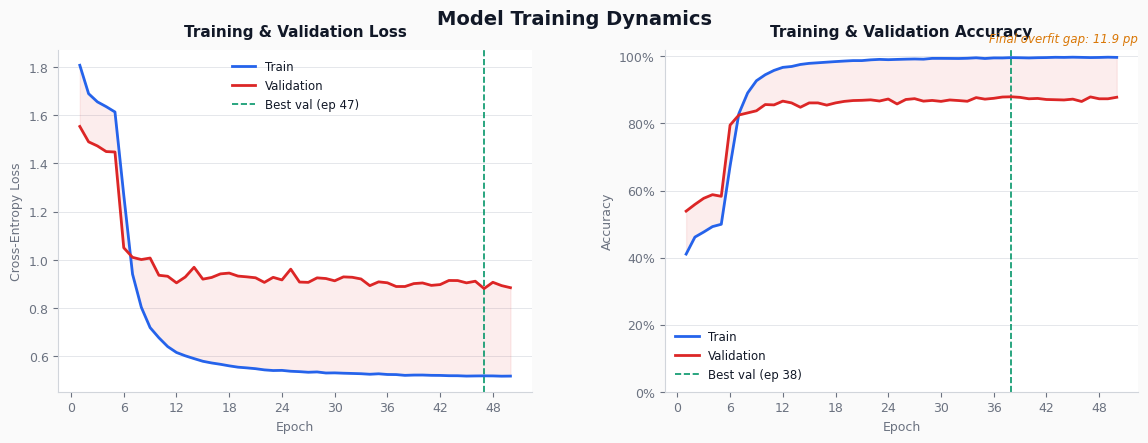

Saved → figures/02_confusion_matrix.png


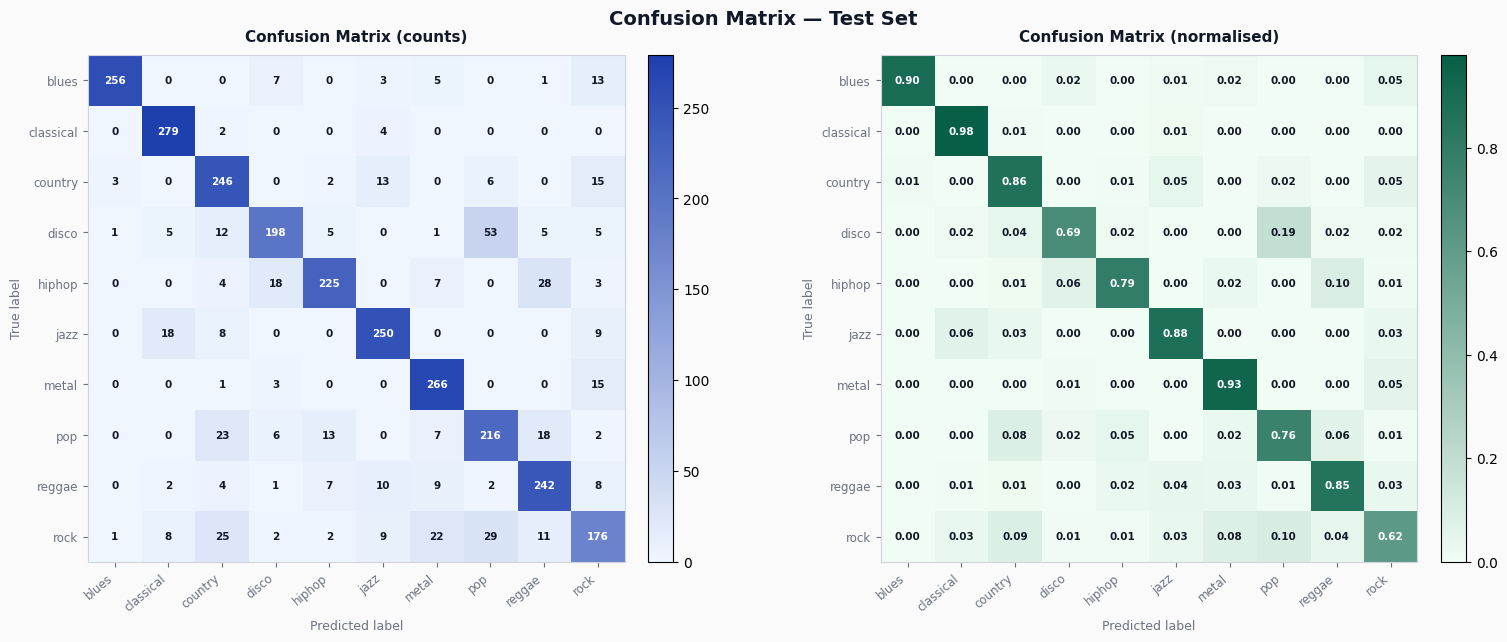

Saved → figures/03_per_class_metrics.png


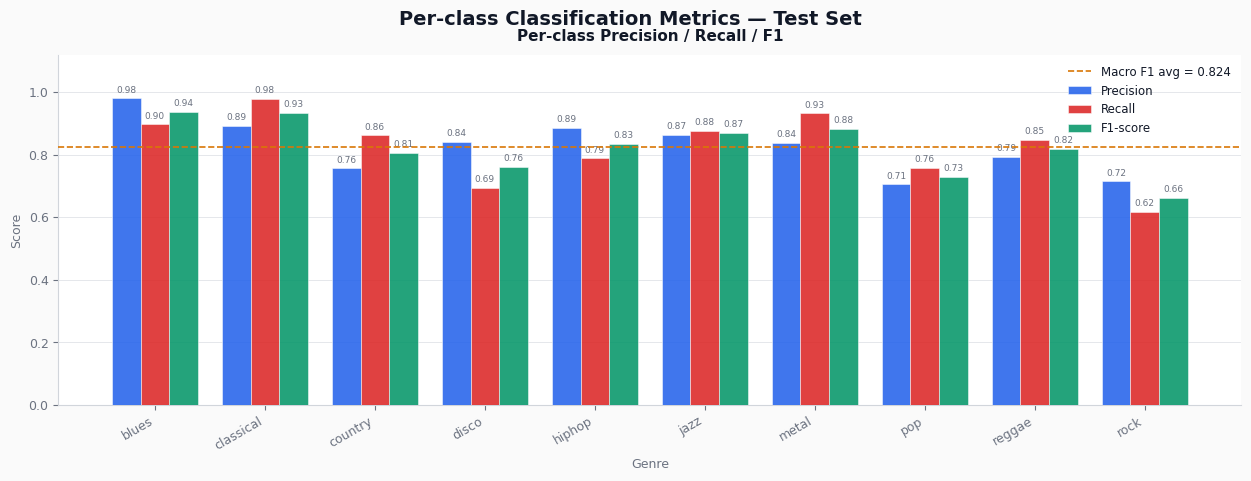

Saved → figures/04_roc_curves.png


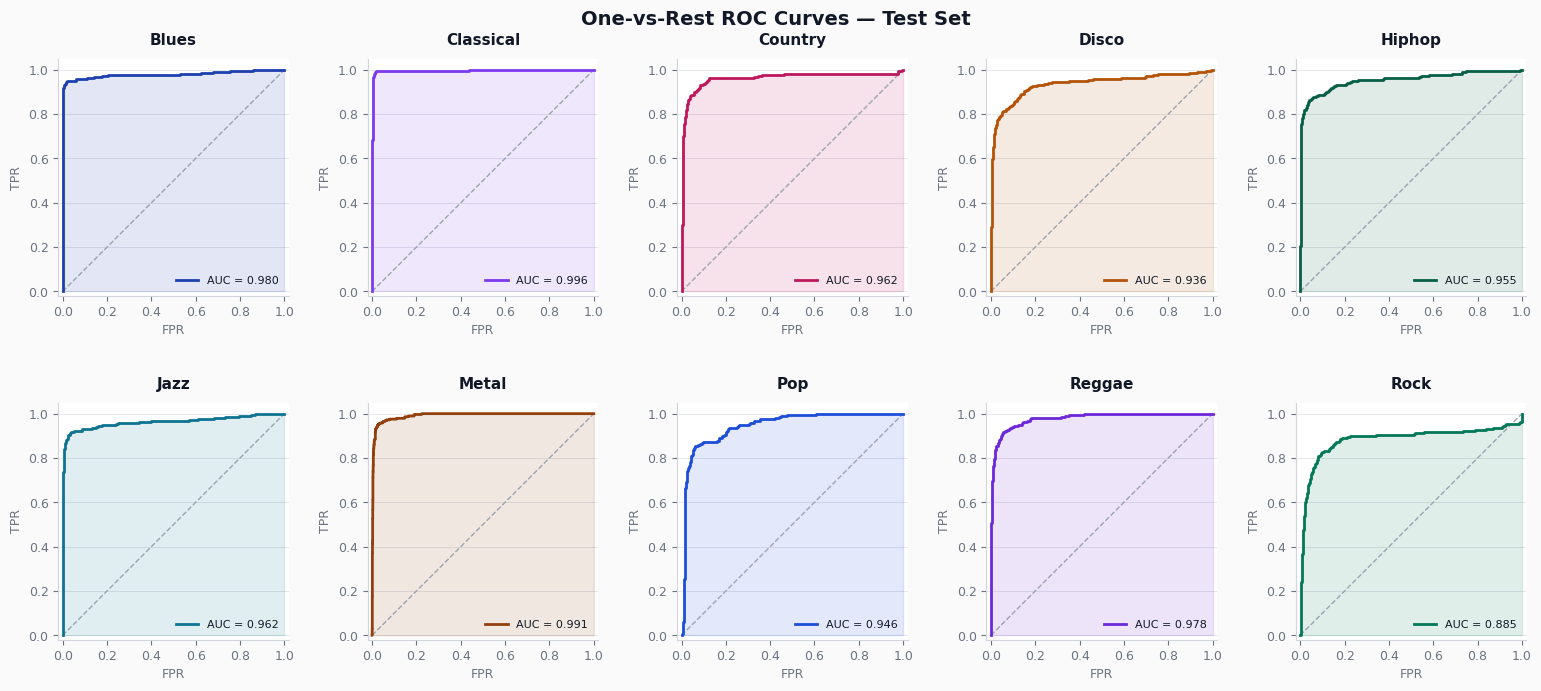

Saved → figures/05_confidence.png


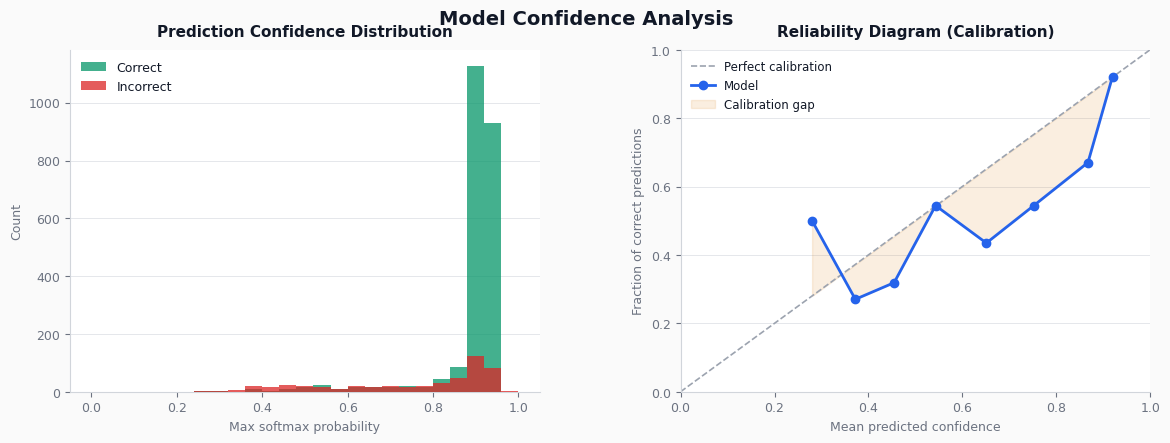

Saved → figures/06_summary_dashboard.png


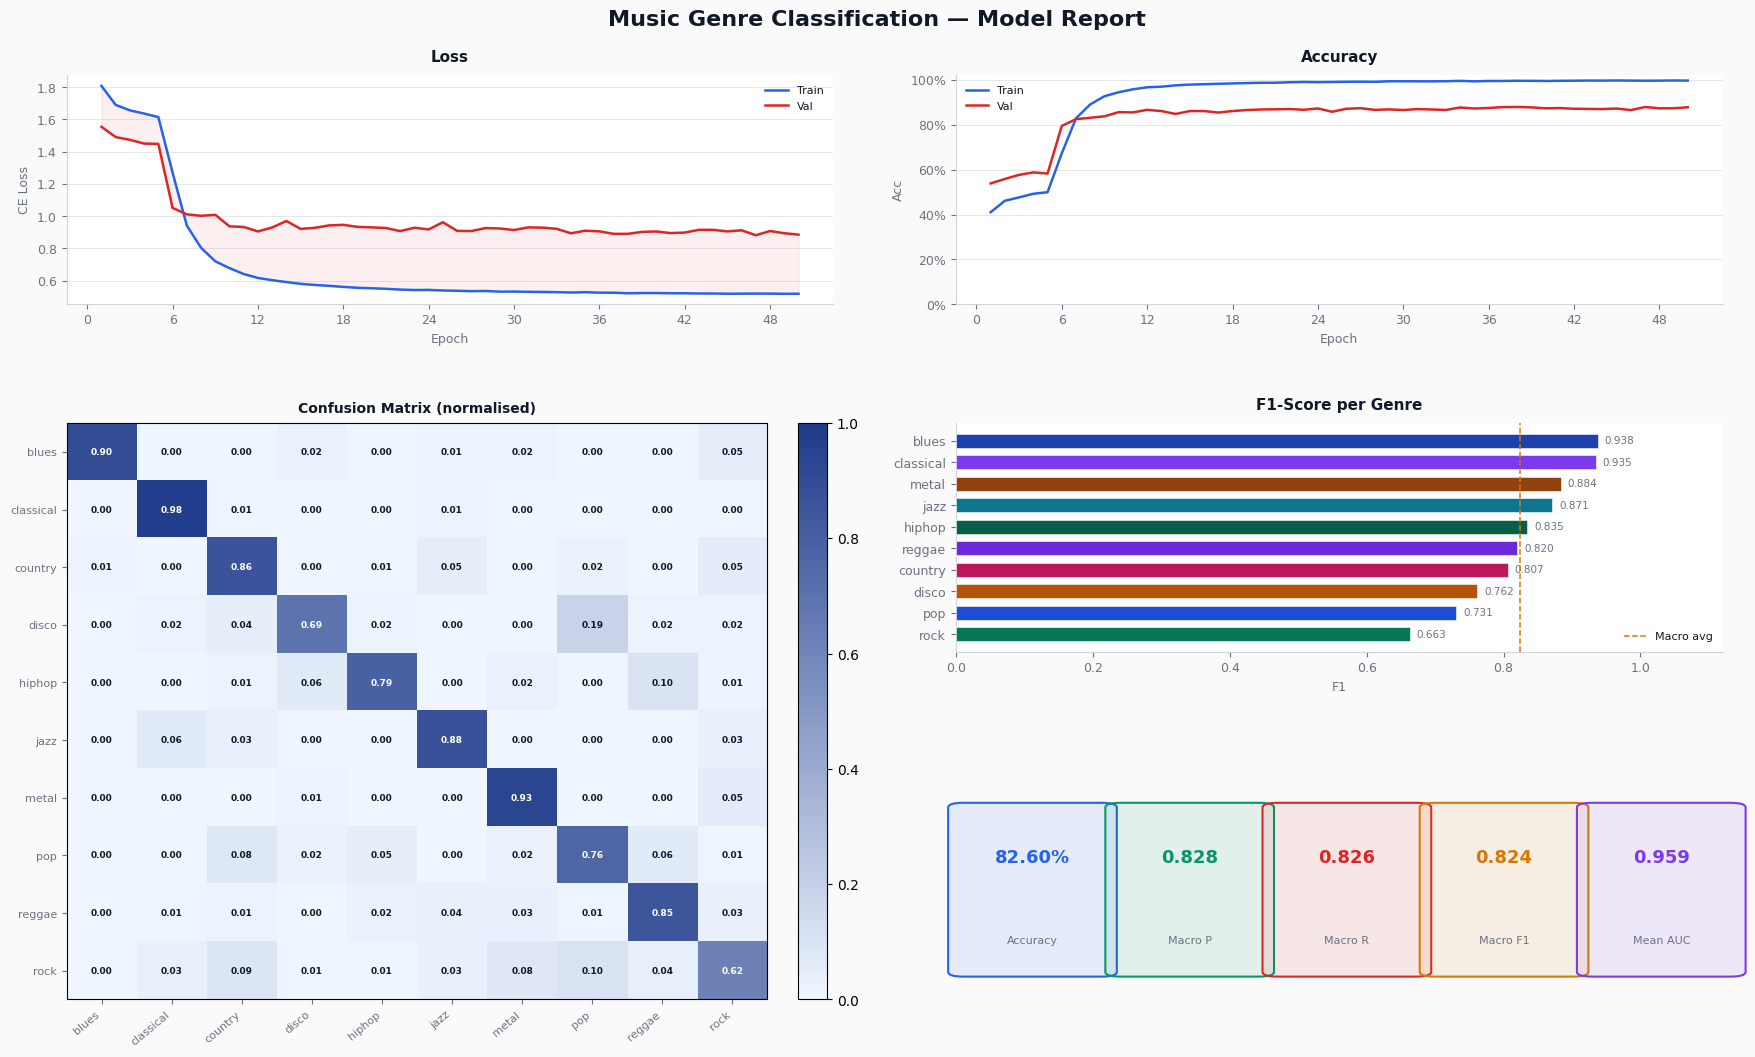


All figures saved to ./figures/


In [16]:
"""
visualize_results.py
====================
Run this AFTER training to generate publication-quality figures.

Usage
-----
    python visualize_results.py

It expects the following variables to already exist in your notebook / session
(they are all produced by the training script):
    - train_losses, val_losses       (lists of floats, one per epoch)
    - train_accs,   val_accs         (lists of floats, one per epoch)
    - model                          (trained ImprovedGenreClassifier)
    - test_loader                    (DataLoader for test set)
    - le                             (fitted LabelEncoder)
    - DEVICE                         (str, 'cuda' or 'cpu')

All figures are saved to  ./figures/  as high-res PNG (300 dpi).
"""

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MaxNLocator
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
)
from sklearn.preprocessing import label_binarize
from itertools import cycle

os.makedirs("figures", exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# Shared style
# ─────────────────────────────────────────────────────────────────────────────
FONT_FAMILY = "DejaVu Sans"

PALETTE = {
    "train":      "#2563EB",   # strong blue
    "val":        "#DC2626",   # strong red
    "grid":       "#E5E7EB",
    "bg":         "#FAFAFA",
    "panel":      "#FFFFFF",
    "text":       "#111827",
    "subtext":    "#6B7280",
    "accent":     "#059669",   # green
    "warn":       "#D97706",
}

# 10-colour genre palette (colorblind-friendly)
GENRE_COLORS = [
    "#1E40AF", "#7C3AED", "#BE185D", "#B45309",
    "#065F46", "#0E7490", "#92400E", "#1D4ED8",
    "#6D28D9", "#047857",
]

def apply_base_style(ax, title="", xlabel="", ylabel="", grid=True):
    ax.set_facecolor(PALETTE["panel"])
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#D1D5DB")
    ax.tick_params(colors=PALETTE["subtext"], labelsize=9)
    ax.xaxis.label.set_color(PALETTE["subtext"])
    ax.yaxis.label.set_color(PALETTE["subtext"])
    if title:
        ax.set_title(title, fontsize=11, fontweight="bold",
                     color=PALETTE["text"], pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9)
    if grid:
        ax.yaxis.grid(True, color=PALETTE["grid"], linewidth=0.7, zorder=0)
        ax.set_axisbelow(True)


# ─────────────────────────────────────────────────────────────────────────────
# Helper: collect predictions on full test set
# ─────────────────────────────────────────────────────────────────────────────
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs  = F.softmax(logits, dim=1).cpu().numpy()
            preds  = logits.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs)
    return (
        np.array(all_labels),
        np.array(all_preds),
        np.array(all_probs),
    )


# ─────────────────────────────────────────────────────────────────────────────
# Figure 1 — Training curves  (loss + accuracy, side by side)
# ─────────────────────────────────────────────────────────────────────────────
def plot_training_curves(train_losses, val_losses, train_accs, val_accs):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                             facecolor=PALETTE["bg"])
    fig.subplots_adjust(hspace=0.35, wspace=0.28,
                        left=0.07, right=0.97, top=0.88, bottom=0.12)

    epochs = range(1, len(train_losses) + 1)

    # ── Loss ──────────────────────────────────────────────────────────────
    ax = axes[0]
    apply_base_style(ax, title="Training & Validation Loss",
                     xlabel="Epoch", ylabel="Cross-Entropy Loss")
    ax.plot(epochs, train_losses, color=PALETTE["train"],
            linewidth=2, label="Train", zorder=3)
    ax.plot(epochs, val_losses,   color=PALETTE["val"],
            linewidth=2, label="Validation", zorder=3)
    ax.fill_between(epochs, train_losses, val_losses,
                    alpha=0.08, color=PALETTE["val"])
    best_val_ep = int(np.argmin(val_losses)) + 1
    ax.axvline(best_val_ep, color=PALETTE["accent"],
               linestyle="--", linewidth=1.2, zorder=2,
               label=f"Best val (ep {best_val_ep})")
    ax.legend(fontsize=8.5, framealpha=0, labelcolor=PALETTE["text"])
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # ── Accuracy ──────────────────────────────────────────────────────────
    ax = axes[1]
    apply_base_style(ax, title="Training & Validation Accuracy",
                     xlabel="Epoch", ylabel="Accuracy")
    ax.plot(epochs, train_accs, color=PALETTE["train"],
            linewidth=2, label="Train", zorder=3)
    ax.plot(epochs, val_accs,   color=PALETTE["val"],
            linewidth=2, label="Validation", zorder=3)
    ax.fill_between(epochs, train_accs, val_accs,
                    alpha=0.08, color=PALETTE["val"])
    best_acc_ep = int(np.argmax(val_accs)) + 1
    ax.axvline(best_acc_ep, color=PALETTE["accent"],
               linestyle="--", linewidth=1.2, zorder=2,
               label=f"Best val (ep {best_acc_ep})")
    ax.set_ylim(0, 1.02)
    ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=8.5, framealpha=0, labelcolor=PALETTE["text"])
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Annotation — final gap
    gap = train_accs[-1] - val_accs[-1]
    fig.text(0.97, 0.92,
             f"Final overfit gap: {gap*100:.1f} pp",
             ha="right", va="top", fontsize=8.5,
             color=PALETTE["warn"], style="italic")

    fig.suptitle("Model Training Dynamics", fontsize=14,
                 fontweight="bold", color=PALETTE["text"], y=0.97)

    plt.savefig("figures/01_training_curves.png", dpi=300,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    print("Saved → figures/01_training_curves.png")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Figure 2 — Confusion matrix
# ─────────────────────────────────────────────────────────────────────────────
def plot_confusion_matrix(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5),
                             facecolor=PALETTE["bg"])
    fig.subplots_adjust(wspace=0.35, left=0.05, right=0.97,
                        top=0.90, bottom=0.12)

    cmap_raw  = LinearSegmentedColormap.from_list(
        "blues_custom", ["#EFF6FF", "#1E40AF"], N=256)
    cmap_norm = LinearSegmentedColormap.from_list(
        "greens_custom", ["#F0FDF4", "#065F46"], N=256)

    for ax, data, cmap, fmt, title in [
        (axes[0], cm,      cmap_raw,  "d",    "Confusion Matrix (counts)"),
        (axes[1], cm_norm, cmap_norm, ".2f",  "Confusion Matrix (normalised)"),
    ]:
        im = ax.imshow(data, cmap=cmap, aspect="auto", vmin=0,
                       vmax=data.max())
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        thresh = data.max() / 2.0
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = data[i, j]
                color = "white" if val > thresh else PALETTE["text"]
                ax.text(j, i, format(val, fmt),
                        ha="center", va="center",
                        fontsize=7.5, color=color, fontweight="bold")

        ax.set_xticks(range(len(class_names)))
        ax.set_yticks(range(len(class_names)))
        ax.set_xticklabels(class_names, rotation=40, ha="right", fontsize=8.5)
        ax.set_yticklabels(class_names, fontsize=8.5)
        ax.set_xlabel("Predicted label", fontsize=9,
                      color=PALETTE["subtext"])
        ax.set_ylabel("True label", fontsize=9,
                      color=PALETTE["subtext"])
        ax.set_title(title, fontsize=11, fontweight="bold",
                     color=PALETTE["text"], pad=10)
        ax.spines[:].set_color("#D1D5DB")
        ax.tick_params(colors=PALETTE["subtext"])

    fig.suptitle("Confusion Matrix — Test Set", fontsize=14,
                 fontweight="bold", color=PALETTE["text"], y=0.97)

    plt.savefig("figures/02_confusion_matrix.png", dpi=300,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    print("Saved → figures/02_confusion_matrix.png")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Figure 3 — Per-class metrics bar chart
# ─────────────────────────────────────────────────────────────────────────────
def plot_per_class_metrics(y_true, y_pred, class_names):
    report = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True
    )

    metrics   = ["precision", "recall", "f1-score"]
    x         = np.arange(len(class_names))
    bar_w     = 0.26
    bar_colors = [PALETTE["train"], PALETTE["val"], PALETTE["accent"]]

    fig, ax = plt.subplots(figsize=(13, 5), facecolor=PALETTE["bg"])
    fig.subplots_adjust(left=0.06, right=0.97, top=0.88, bottom=0.18)
    apply_base_style(ax, title="Per-class Precision / Recall / F1",
                     xlabel="Genre", ylabel="Score")

    for i, (metric, color) in enumerate(zip(metrics, bar_colors)):
        vals = [report[c][metric] for c in class_names]
        bars = ax.bar(x + (i - 1) * bar_w, vals,
                      width=bar_w, color=color, alpha=0.88,
                      label=metric.capitalize(), zorder=3,
                      edgecolor="white", linewidth=0.4)
        for bar, v in zip(bars, vals):
            if v > 0.06:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.012,
                        f"{v:.2f}", ha="center", va="bottom",
                        fontsize=6.5, color=PALETTE["subtext"])

    # Macro avg line
    macro_f1 = report["macro avg"]["f1-score"]
    ax.axhline(macro_f1, color=PALETTE["warn"], linestyle="--",
               linewidth=1.2, zorder=4,
               label=f"Macro F1 avg = {macro_f1:.3f}")

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=8.5, framealpha=0, labelcolor=PALETTE["text"],
              loc="upper right")

    fig.suptitle("Per-class Classification Metrics — Test Set",
                 fontsize=14, fontweight="bold",
                 color=PALETTE["text"], y=0.97)

    plt.savefig("figures/03_per_class_metrics.png", dpi=300,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    print("Saved → figures/03_per_class_metrics.png")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Figure 4 — One-vs-Rest ROC curves
# ─────────────────────────────────────────────────────────────────────────────
def plot_roc_curves(y_true, y_probs, class_names):
    n_classes   = len(class_names)
    y_bin       = label_binarize(y_true, classes=range(n_classes))

    fig, axes = plt.subplots(2, 5, figsize=(16, 7),
                             facecolor=PALETTE["bg"])
    fig.subplots_adjust(hspace=0.45, wspace=0.32,
                        left=0.05, right=0.97,
                        top=0.90, bottom=0.07)

    for i, (ax, name) in enumerate(zip(axes.flat, class_names)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_probs[:, i])
        roc_auc     = auc(fpr, tpr)
        color       = GENRE_COLORS[i % len(GENRE_COLORS)]

        ax.plot(fpr, tpr, color=color, lw=2,
                label=f"AUC = {roc_auc:.3f}", zorder=3)
        ax.fill_between(fpr, tpr, alpha=0.12, color=color)
        ax.plot([0, 1], [0, 1], "--", color="#9CA3AF", lw=1, zorder=2)
        ax.set_xlim([-0.02, 1.02])
        ax.set_ylim([-0.02, 1.05])

        apply_base_style(ax, title=name.capitalize(),
                         xlabel="FPR", ylabel="TPR")
        ax.legend(fontsize=8, framealpha=0, loc="lower right",
                  labelcolor=PALETTE["text"])
        ax.set_aspect("equal")

    fig.suptitle("One-vs-Rest ROC Curves — Test Set",
                 fontsize=14, fontweight="bold",
                 color=PALETTE["text"], y=0.97)

    plt.savefig("figures/04_roc_curves.png", dpi=300,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    print("Saved → figures/04_roc_curves.png")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Figure 5 — Confidence distribution (correct vs incorrect)
# ─────────────────────────────────────────────────────────────────────────────
def plot_confidence_distribution(y_true, y_pred, y_probs):
    max_conf   = y_probs.max(axis=1)
    correct    = (y_true == y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5),
                             facecolor=PALETTE["bg"])
    fig.subplots_adjust(wspace=0.3, left=0.07, right=0.97,
                        top=0.88, bottom=0.12)

    bins = np.linspace(0, 1, 26)

    # ── Histogram ─────────────────────────────────────────────────────────
    ax = axes[0]
    apply_base_style(ax,
                     title="Prediction Confidence Distribution",
                     xlabel="Max softmax probability",
                     ylabel="Count")
    ax.hist(max_conf[correct],  bins=bins, color=PALETTE["accent"],
            alpha=0.75, label="Correct",   zorder=3)
    ax.hist(max_conf[~correct], bins=bins, color=PALETTE["val"],
            alpha=0.75, label="Incorrect", zorder=3)
    ax.legend(fontsize=9, framealpha=0, labelcolor=PALETTE["text"])

    # ── Calibration (reliability diagram) ─────────────────────────────────
    ax = axes[1]
    apply_base_style(ax,
                     title="Reliability Diagram (Calibration)",
                     xlabel="Mean predicted confidence",
                     ylabel="Fraction of correct predictions")

    bin_edges   = np.linspace(0, 1, 11)
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2
    frac_correct, mean_conf = [], []

    for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
        mask = (max_conf >= lo) & (max_conf < hi)
        if mask.sum() > 0:
            frac_correct.append(correct[mask].mean())
            mean_conf.append(max_conf[mask].mean())

    ax.plot([0, 1], [0, 1], "--", color="#9CA3AF", lw=1.2,
            label="Perfect calibration", zorder=2)
    ax.plot(mean_conf, frac_correct, "o-",
            color=PALETTE["train"], linewidth=2,
            markersize=6, zorder=3, label="Model")
    ax.fill_between(mean_conf, frac_correct, mean_conf,
                    alpha=0.12, color=PALETTE["warn"],
                    label="Calibration gap")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=8.5, framealpha=0, labelcolor=PALETTE["text"])

    fig.suptitle("Model Confidence Analysis", fontsize=14,
                 fontweight="bold", color=PALETTE["text"], y=0.97)

    plt.savefig("figures/05_confidence.png", dpi=300,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    print("Saved → figures/05_confidence.png")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Figure 6 — Summary dashboard  (single-page overview)
# ─────────────────────────────────────────────────────────────────────────────
def plot_summary_dashboard(
    train_losses, val_losses,
    train_accs,   val_accs,
    y_true, y_pred, y_probs,
    class_names,
):
    report   = classification_report(
        y_true, y_pred, target_names=class_names, output_dict=True
    )
    cm_norm  = confusion_matrix(y_true, y_pred).astype(float)
    cm_norm /= cm_norm.sum(axis=1, keepdims=True)

    fig = plt.figure(figsize=(18, 11), facecolor=PALETTE["bg"])
    gs  = gridspec.GridSpec(
        3, 4,
        figure=fig,
        hspace=0.52, wspace=0.38,
        left=0.05, right=0.97,
        top=0.91, bottom=0.07,
    )

    epochs = range(1, len(train_losses) + 1)

    # ── [0,0:2]  Loss curve ────────────────────────────────────────────────
    ax_loss = fig.add_subplot(gs[0, 0:2])
    apply_base_style(ax_loss, title="Loss", xlabel="Epoch", ylabel="CE Loss")
    ax_loss.plot(epochs, train_losses, color=PALETTE["train"], lw=1.8, label="Train")
    ax_loss.plot(epochs, val_losses,   color=PALETTE["val"],   lw=1.8, label="Val")
    ax_loss.fill_between(epochs, train_losses, val_losses, alpha=0.07, color=PALETTE["val"])
    ax_loss.legend(fontsize=8, framealpha=0, labelcolor=PALETTE["text"])
    ax_loss.xaxis.set_major_locator(MaxNLocator(integer=True))

    # ── [0,2:4]  Accuracy curve ────────────────────────────────────────────
    ax_acc = fig.add_subplot(gs[0, 2:4])
    apply_base_style(ax_acc, title="Accuracy", xlabel="Epoch", ylabel="Acc")
    ax_acc.plot(epochs, train_accs, color=PALETTE["train"], lw=1.8, label="Train")
    ax_acc.plot(epochs, val_accs,   color=PALETTE["val"],   lw=1.8, label="Val")
    ax_acc.set_ylim(0, 1.02)
    ax_acc.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
    ax_acc.legend(fontsize=8, framealpha=0, labelcolor=PALETTE["text"])
    ax_acc.xaxis.set_major_locator(MaxNLocator(integer=True))

    # ── [1,0:2]  Normalised confusion matrix ──────────────────────────────
    ax_cm = fig.add_subplot(gs[1:, 0:2])
    cmap  = LinearSegmentedColormap.from_list(
        "cm_blue", ["#EFF6FF", "#1E3A8A"], N=256
    )
    im = ax_cm.imshow(cm_norm, cmap=cmap, aspect="auto", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            v = cm_norm[i, j]
            ax_cm.text(j, i, f"{v:.2f}",
                       ha="center", va="center",
                       fontsize=6.5,
                       color="white" if v > 0.5 else PALETTE["text"],
                       fontweight="bold")
    ax_cm.set_xticks(range(len(class_names)))
    ax_cm.set_yticks(range(len(class_names)))
    ax_cm.set_xticklabels(class_names, rotation=40, ha="right", fontsize=8)
    ax_cm.set_yticklabels(class_names, fontsize=8)
    ax_cm.set_title("Confusion Matrix (normalised)", fontsize=10,
                    fontweight="bold", color=PALETTE["text"], pad=8)
    ax_cm.tick_params(colors=PALETTE["subtext"])

    # ── [1,2:4]  F1 horizontal bar chart ──────────────────────────────────
    ax_f1 = fig.add_subplot(gs[1, 2:4])
    apply_base_style(ax_f1, title="F1-Score per Genre",
                     xlabel="F1", ylabel="")
    f1_vals  = [report[c]["f1-score"] for c in class_names]
    sorted_idx = np.argsort(f1_vals)
    colors_f1  = [GENRE_COLORS[i % len(GENRE_COLORS)] for i in sorted_idx]
    bars = ax_f1.barh(
        [class_names[i] for i in sorted_idx],
        [f1_vals[i] for i in sorted_idx],
        color=colors_f1, edgecolor="white", linewidth=0.4,
        height=0.65, zorder=3
    )
    for bar, v in zip(bars, [f1_vals[i] for i in sorted_idx]):
        ax_f1.text(v + 0.01, bar.get_y() + bar.get_height() / 2,
                   f"{v:.3f}", va="center", fontsize=7.5,
                   color=PALETTE["subtext"])
    ax_f1.set_xlim(0, 1.12)
    ax_f1.axvline(report["macro avg"]["f1-score"],
                  color=PALETTE["warn"], linestyle="--",
                  linewidth=1.1, zorder=4, label="Macro avg")
    ax_f1.legend(fontsize=8, framealpha=0, labelcolor=PALETTE["text"])
    ax_f1.yaxis.grid(False)

    # ── [2,2:4]  Macro metrics summary cards ──────────────────────────────
    ax_stats = fig.add_subplot(gs[2, 2:4])
    ax_stats.axis("off")

    overall_acc = (y_true == y_pred).mean()
    macro_p     = report["macro avg"]["precision"]
    macro_r     = report["macro avg"]["recall"]
    macro_f1    = report["macro avg"]["f1-score"]
    n_classes   = len(class_names)
    y_bin       = label_binarize(y_true, classes=range(n_classes))
    aucs        = [auc(*roc_curve(y_bin[:, i], y_probs[:, i])[:2])
                   for i in range(n_classes)]
    mean_auc    = np.mean(aucs)

    stats = [
        ("Accuracy",   f"{overall_acc*100:.2f}%", PALETTE["train"]),
        ("Macro P",    f"{macro_p:.3f}",           PALETTE["accent"]),
        ("Macro R",    f"{macro_r:.3f}",           PALETTE["val"]),
        ("Macro F1",   f"{macro_f1:.3f}",          PALETTE["warn"]),
        ("Mean AUC",   f"{mean_auc:.3f}",          "#7C3AED"),
    ]

    card_w, card_h = 0.18, 0.72
    gap = 0.205
    for k, (label, val, color) in enumerate(stats):
        x0 = 0.01 + k * gap
        rect = mpatches.FancyBboxPatch(
            (x0, 0.12), card_w, card_h,
            boxstyle="round,pad=0.02",
            linewidth=1.5,
            edgecolor=color,
            facecolor=color + "18",
            transform=ax_stats.transAxes,
            clip_on=False,
        )
        ax_stats.add_patch(rect)
        ax_stats.text(x0 + card_w / 2, 0.62, val,
                      transform=ax_stats.transAxes,
                      ha="center", va="center",
                      fontsize=13, fontweight="bold", color=color)
        ax_stats.text(x0 + card_w / 2, 0.26, label,
                      transform=ax_stats.transAxes,
                      ha="center", va="center",
                      fontsize=8, color=PALETTE["subtext"])

    fig.suptitle(
        "Music Genre Classification — Model Report",
        fontsize=16, fontweight="bold",
        color=PALETTE["text"], y=0.97
    )

    plt.savefig("figures/06_summary_dashboard.png", dpi=300,
                bbox_inches="tight", facecolor=PALETTE["bg"])
    print("Saved → figures/06_summary_dashboard.png")
    plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# Entry point — paste this block at the end of your notebook
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":

    # ── Collect predictions ────────────────────────────────────────────────
    print("Collecting predictions on test set...")
    y_true, y_pred, y_probs = get_predictions(model, test_loader, DEVICE)
    class_names = list(le.classes_)

    # ── Render all figures ─────────────────────────────────────────────────
    print("\nRendering figures...\n")
    plot_training_curves(train_losses, val_losses, train_accs, val_accs)
    plot_confusion_matrix(y_true, y_pred, class_names)
    plot_per_class_metrics(y_true, y_pred, class_names)
    plot_roc_curves(y_true, y_probs, class_names)
    plot_confidence_distribution(y_true, y_pred, y_probs)
    plot_summary_dashboard(
        train_losses, val_losses,
        train_accs,   val_accs,
        y_true, y_pred, y_probs,
        class_names,
    )
    print("\nAll figures saved to ./figures/")